In [166]:
import pandas as pd
from geopy.geocoders import ArcGIS
import time
import eurostat
from geodatasets import get_path
import geopandas as gpd
import matplotlib.pyplot as plt
from geopy.geocoders import ArcGIS
import time
from geopy.exc import GeocoderTimedOut, GeocoderUnavailable
import folium

In [144]:

# City population dataset from Eurostat
print("Fetching data from Eurostat...")
dataset_code = 'urb_cpop1'
df = eurostat.get_data_df(dataset_code)

# 'indic_ur' == 'DE1001V' is the Eurostat code for "Jan 1 Total Population"
df_pop = df[df['indic_ur'] == 'DE1001V'].copy()
df_pop.head()

Fetching data from Eurostat...


,freq,indic_ur,cities\TIME_PERIOD,1989,1990,1991,1992,1993,1994,1995,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,A,DE1001V,AT,NaN,NaN,7795786.0,7867796.0,7962003.0,8015027.0,8039865.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,A,DE1001V,AT001C,NaN,NaN,1539848.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,A,DE1001V,AT002C,NaN,NaN,237810.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,A,DE1001V,AT003C,NaN,NaN,203044.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,A,DE1001V,AT004C,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [145]:
# Extract city codes from data set
city_codes = df_pop['cities\\TIME_PERIOD']
city_codes = city_codes.values.tolist() # Convert to list
df_pop.rename(columns={'cities\\TIME_PERIOD':'city_code'}, inplace=True)
# Extract year columns and put them in a ordered list with newest at the top
year_columns = [col for col in df_pop.columns if col.isdigit()]
year_columns.sort(reverse=True)

In [146]:
# Replaces all Nan with the newest data point and fills it all in the first column, then we extract that column and save it as population
df_pop['population'] = df_pop[year_columns].bfill(axis='columns').iloc[:, 0]
df_pop = df_pop[['city_code', 'population']].dropna()
# Keep only rows where the string length of the city code is strictly greater than 2
df_pop = df_pop[df_pop['city_code'].astype(str).str.len() > 2]
print("2. Fetching Official City Names...")
# Get names and map them to the codes
dic = eurostat.get_dic('urb_cpop1', 'cities')
if not dic:
    dic = eurostat.get_dic('urb_cpop1', 'geo')

df_pop['city_name'] = df_pop['city_code'].map(dict(dic))

2. Fetching Official City Names...


In [147]:
df_pop

,city_code,population,city_name
1,AT001C,1766746.0,Wien (greater city)
2,AT002C,269997.0,Graz
3,AT003C,193814.0,Linz (greater city)
4,AT004C,146631.0,Salzburg
5,AT005C,124579.0,Innsbruck
...,...,...,...
960,UK131C,70184.0,Corby
961,UK132C,100759.0,Kettering
962,UK133C,78455.0,Inverclyde (Greenock)
963,UK134C,177310.0,Renfrewshire (Paisley)


In [167]:

# 1. Check if you already have the file
try:
    final_map_data = pd.read_csv('final_city_coordinates.csv')
    print("Loaded existing data from disk!")
except FileNotFoundError:
    print("No file found, starting the one-time geocoding process...")

    # THE FIX 1: Give the server 10 seconds to reply instead of 1!
    geolocator = ArcGIS(timeout=10)
    latitudes, longitudes = [], []

    for idx, row in df_pop.iterrows():
        country_code = str(row['city_code'])[:2]
        search_string = f"{row['city_name']}, {country_code}"

        print(f"Searching for: {search_string}...")

        # THE FIX 2: The Safety Net. If it times out, print a warning but KEEP GOING.
        try:
            location = geolocator.geocode(search_string)
            if location:
                latitudes.append(location.latitude)
                longitudes.append(location.longitude)
            else:
                latitudes.append(None)
                longitudes.append(None)

        except (GeocoderTimedOut, GeocoderUnavailable):
            print(f"  -> WARNING: Server hiccuped on {search_string}. Skipping.")
            latitudes.append(None)
            longitudes.append(None)

        time.sleep(1)  # Polite delay

    df_pop['latitude'] = latitudes
    df_pop['longitude'] = longitudes
    final_map_data = df_pop.dropna(subset=['latitude', 'longitude'])

    # SAVE IT!
    final_map_data.to_csv('final_city_coordinates.csv', index=False)
    print("Geocoding complete and saved to 'final_city_coordinates.csv'!")

# Now you can use final_map_data for your Folium map whenever you want

No file found, starting the one-time geocoding process...
Searching for: Wien (greater city), AT...
Searching for: Graz, AT...
Searching for: Linz (greater city), AT...
Searching for: Salzburg, AT...
Searching for: Innsbruck, AT...
Searching for: Klagenfurt, AT...
Searching for: Bruxelles/Brussel (greater city), BE...
Searching for: Antwerpen (greater city), BE...
Searching for: Gent, BE...
Searching for: Charleroi (greater city), BE...
Searching for: Liège (greater city), BE...
Searching for: Brugge, BE...
Searching for: Namur, BE...
Searching for: Leuven, BE...
Searching for: Mons (greater city), BE...
Searching for: Kortrijk (greater city), BE...
Searching for: Oostende (greater city), BE...
Searching for: Mechelen, BE...
Searching for: Mouscron, BE...
Searching for: La Louvière (greater city), BE...
Searching for: Verviers (greater city), BE...
Searching for: Sofia, BG...
Searching for: Plovdiv, BG...
Searching for: Varna, BG...
Searching for: Burgas, BG...
Searching for: Pleven, B

In [177]:

# 1. Load the data
df = pd.read_csv('final_city_coordinates.csv')

# 2. Find any row that contains the word "Lille"
lille_filter = df['city_name'].str.contains('Lille', case=False, na=False)

# Print out what Eurostat actually called it and its current (wrong) coordinates
print("Found this in your data:")
print(df.loc[lille_filter, ['city_name', 'latitude', 'longitude']])

# 3. Force the correct coordinates into that exact row
df.loc[lille_filter, 'latitude'] = 50.6292
df.loc[lille_filter, 'longitude'] = 3.0573

# 4. Save it back to the file
df.to_csv('final_city_coordinates.csv', index=False)
print("\nSuccess! Lille has been permanently relocated to France.")

Found this in your data:
                city_name  latitude  longitude
364  Lille (greater city)  38.66266  -90.23175

Success! Lille has been permanently relocated to France.


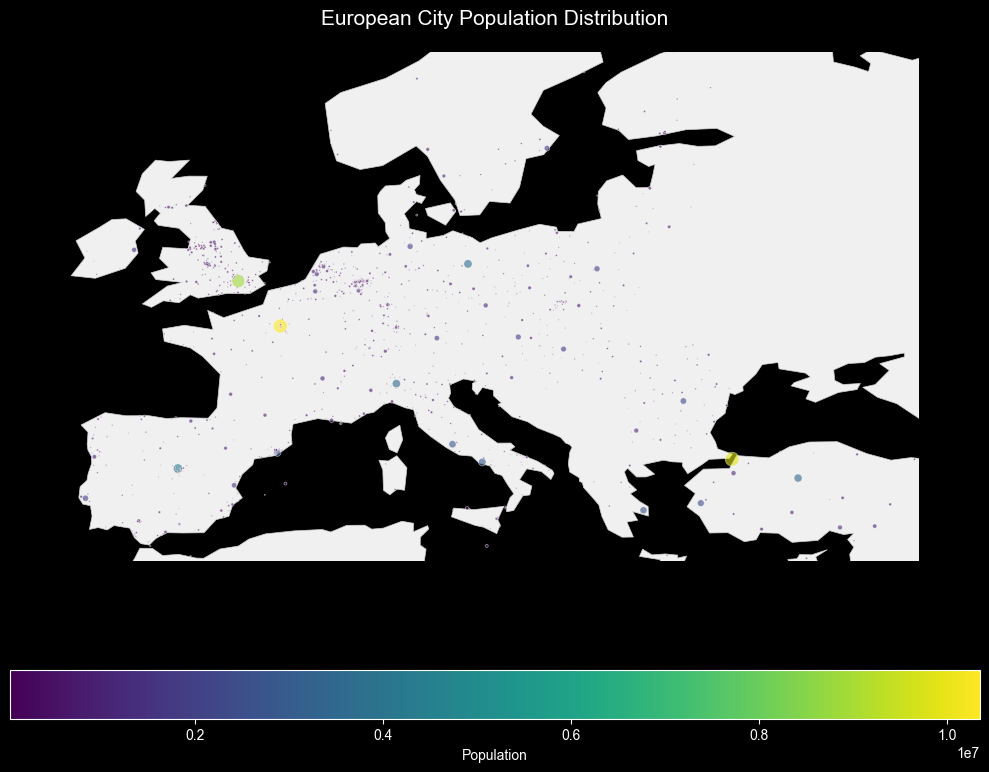

In [172]:


# 1. Convert your DataFrame to a GeoDataFrame
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.longitude, df.latitude)
)

# 2. Get a world map to use as a background layer
world = gpd.read_file(get_path('naturalearth.land'))

# 1. Create the plot with a cleaner style
fig, ax = plt.subplots(figsize=(10, 8))
ax.set_axis_off() # Removes the ugly box and axis numbers

# 2. Plot the land with a softer background color
world.plot(ax=ax, color='#f0f0f0', edgecolor='#d0d0d0', linewidth=0.5)

# 3. Plot your cities with better aesthetics
gdf.plot(
    ax=ax,
    column='population',
    markersize=gdf['population'] / 100000, # Adjust scale if bubbles are too big
    cmap='viridis', # A more professional color map
    alpha=0.6,
    edgecolor='white',
    linewidth=0.5,
    legend=True,
    legend_kwds={'label': "Population", 'orientation': "horizontal"}
)

# 4. Refine the view
ax.set_xlim(-10, 40)
ax.set_ylim(35, 65)
plt.title("European City Population Distribution", fontsize=15, pad=20)
plt.tight_layout()

plt.show()

In [162]:
import folium


# 1. Load your perfect, finalized data
df = pd.read_csv('final_city_coordinates.csv')

# 2. Initialize the map (centered on Europe)
m = folium.Map(location=[50.0, 10.0], zoom_start=4, tiles="CartoDB positron")

# 3. Add the bubbles
for idx, row in df.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=min(max(row['population'] / 100000, 3), 15), # Scale bubble size
        popup=f"<b>{row['city_name']}</b><br>Pop: {int(row['population']):,}",
        color="crimson",
        fill=True,
        fill_opacity=0.6
    ).add_to(m)

# 4. Save it as a local website file
m.save("my_european_map.html")
print("Interactive map saved! Open 'my_european_map.html' in your browser.")

Interactive map saved! Open 'my_european_map.html' in your browser.


In [178]:

# 2. THE FILTER: Keep only cities with a population greater than 100,000
# (You can change this number to 50000 or 250000 depending on what you want to see)
POPULATION_MINIMUM = 100000
df_filtered = df[df['population'] >= POPULATION_MINIMUM].copy()

print(f"Filtered down to {len(df_filtered)} major cities.")

# 3. THE COLOR FUNCTION: Assign colors based on population tiers
def get_color(pop):
    if pop >= 1000000:
        return '#800026'  # Dark Red (Megacities: 1M+)
    elif pop >= 500000:
        return '#E31A1C'  # Bright Red (Very Large: 500k - 1M)
    elif pop >= 250000:
        return '#FD8D3C'  # Orange (Large: 250k - 500k)
    else:
        return '#FEB24C'  # Yellow/Gold (Medium: 100k - 250k)

# 4. Initialize the map
m = folium.Map(location=[50.0, 10.0], zoom_start=4, tiles="CartoDB positron")

# 5. Add the color-coded bubbles
for idx, row in df_filtered.iterrows():
    pop = row['population']
    city_color = get_color(pop)

    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=min(max(pop / 100000, 3), 15), # Scale bubble size
        popup=f"<b>{row['city_name']}</b><br>Pop: {int(pop):,}",
        color=city_color,         # Border color
        fill=True,
        fill_color=city_color,    # Inside color
        fill_opacity=0.7
    ).add_to(m)

# 6. Save it
m.save("european_map_colored.html")
print("Map saved! Open 'european_map_colored.html' to see the changes.")

Filtered down to 579 major cities.
Map saved! Open 'european_map_colored.html' to see the changes.
